In [1]:
library(Seurat)
library(tidyverse)

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.3     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all confli

In [2]:
tosti.cp <- readRDS("./data/rdsFiles/tosti_pancreas.epi.chronic_pancreatitis.rds")
ma.pinjury <- readRDS("./data/rdsFiles/ma_pancreas_injury.yfpPositive.rds")
burdziak.pdac <- readRDS("./data/rdsFiles/burdziak_pdac_models.progressionCohort.rds")
chen.dis_val <- readRDS("./data/rdsFiles/chen.precancer_crc_states.epi.dis_val.asc_ssc.rds")

# visualizations

## create custom theme

In [3]:
custom_theme_classic <- theme_classic(base_size = 5) + # base_family = "Arial"; issues saving Arial fonts as pdf via ggsave/pdf device/cairopdf
    theme(axis.line = element_line(linewidth = 0.5),
          axis.ticks = element_line(linewidth = 0.5),
          axis.ticks.length = unit(0.5, "mm"),
          plot.title = element_text(size = 5),
          axis.title = element_text(size = 5),
          axis.text = element_text(size = 5),
          legend.text = element_text(size = 5),
          legend.title = element_text(size = 5),
          strip.text = element_text(size = 5))

## umaps showing module scores

### 4a

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


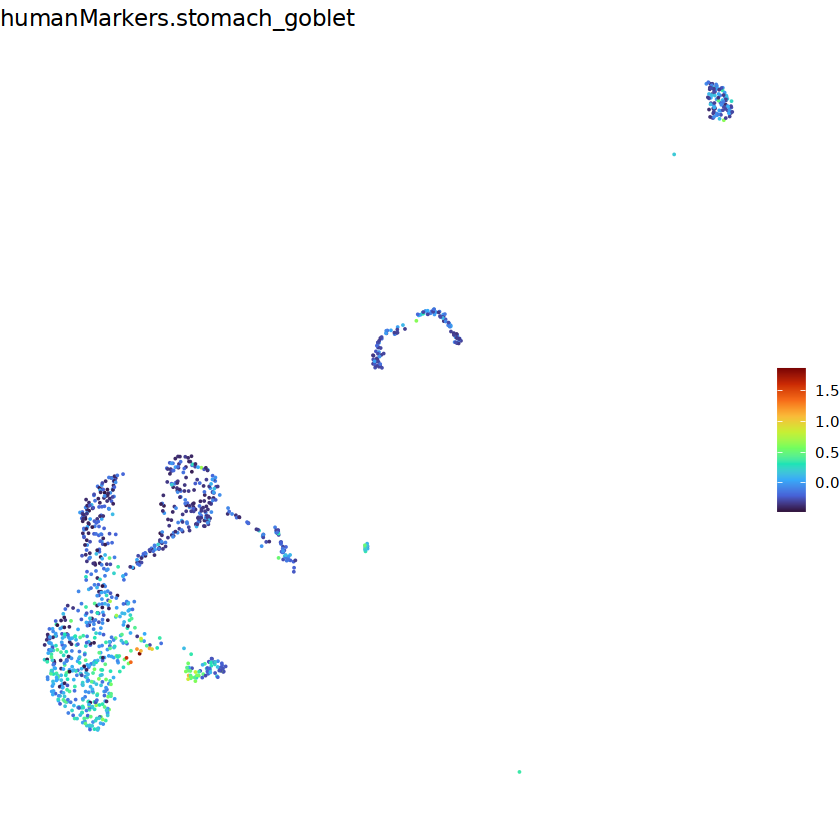

In [4]:
p.4a_umap <- FeaturePlot(object = tosti.cp,  
            pt.size = 0.01,
            reduction = "umap", 
            raster = F,
            features = "humanMarkers.stomach_goblet") & 
    scale_color_gradientn(colors = viridis::turbo(10)) &
    theme_void() & 
    NoAxes()
p.4a_umap

ggsave(filename = "./plots/4a_umap.pdf", plot = p.4a_umap, units = "in", width = 2.4, height = 2.4)

### 4b

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


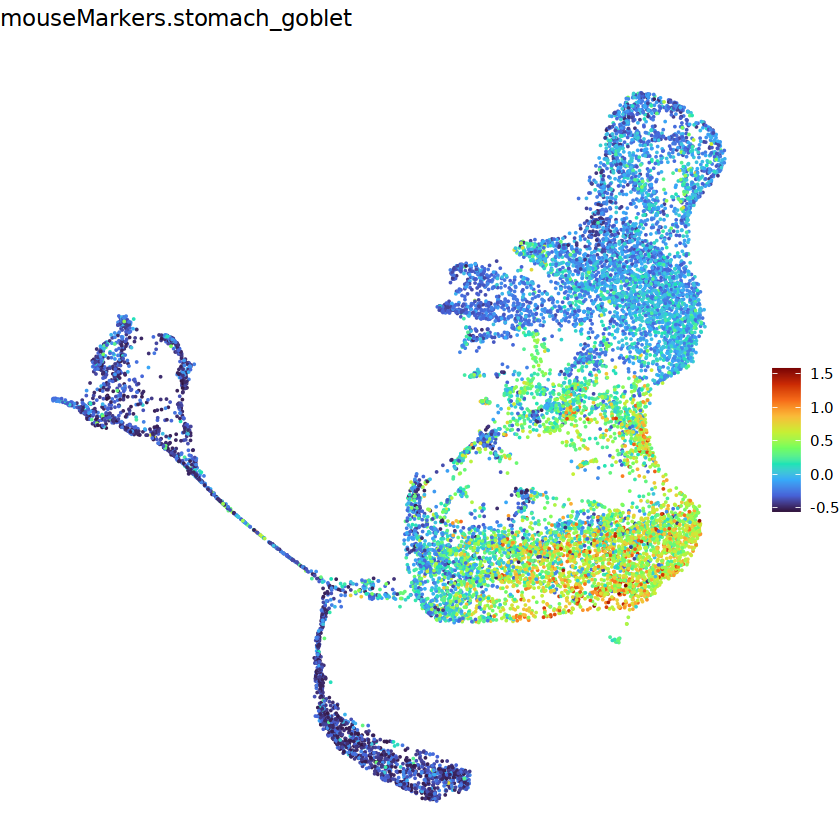

In [5]:
p.4b_umap <- FeaturePlot(object = ma.pinjury,  
            pt.size = 0.01,
            reduction = "umap", 
            raster = F,
            features = "mouseMarkers.stomach_goblet") & 
    scale_color_gradientn(colors = viridis::turbo(10)) &
    theme_void() & 
    NoAxes()
p.4b_umap

ggsave(filename = "./plots/4b_umap.pdf", plot = p.4b_umap, units = "in", width = 2.4, height = 2.4)

## violin plots

### custom violin plot functions

In [6]:
makeViolinPlot <- function(obj = ma.pinjury, 
                           plotTitle = "Ma Pancreas injury", 
                           col.celltype = "cellType",
                           levels.celltype = c("Acinar", "Metaplastic"),
                           moduleA = "mouseMarkers.pancreas_acinar", 
                           moduleB = "mouseMarkers.stomach_goblet", 
                           moduleA.suffix = "A", 
                           moduleB.suffix = "G", 
                           rotation.xtick = 0) {

    # Reshape the data for comparison
    plotDF <- obj@meta.data |>
        select(all_of(c(col.celltype, moduleA, moduleB))) |>
        pivot_longer(cols = c(moduleA, moduleB), 
                     names_to = "module", 
                     values_to = "score") |>
        mutate(moduleAbbr = case_when(module == moduleA ~ moduleA.suffix,
                                      module == moduleB ~ moduleB.suffix, 
                                      .default = NA), 
               celltype.xVar = paste0(!!sym(col.celltype), ".", moduleAbbr)) |> 
        mutate(!!sym(col.celltype) := factor(!!sym(col.celltype), levels = levels.celltype))
    
    # Get unique cell types
    unique_celltypes <- levels(plotDF[[col.celltype]])# unique(plotDF[[col.celltype]])
    
    # Initialize list to store individual plots
    plot_list <- list()

    iterNum <- 1
    # Generate plots for each cell type
    for (celltype in unique_celltypes) {
        # Subset data for the current cell type
        plotDF_subset <- plotDF |> filter(!!sym(col.celltype) == celltype)
        
        # Generate pairwise comparisons for the current cell type
        pairs.celltype <- plotDF_subset |>
            summarise(pairs = list(c(unique(paste0(celltype, ".", moduleA.suffix)), 
                                     unique(paste0(celltype, ".", moduleB.suffix))))) |>
            pull(pairs)
        
        # Create violin plot for the current cell type
        if (iterNum == 1) {
            yLabel = "Module score"
        } else {
            yLabel = ""
        }
        p <- plotDF_subset |> 
            mutate(celltype.xVar = factor(celltype.xVar, levels = unlist(pairs.celltype))) |>
            ggpubr::ggviolin(x = "celltype.xVar",
                             y = "score",
                             fill = "moduleAbbr",
                             palette = setNames(c("#BFBFBF", "#D8A767"), c(moduleA.suffix, moduleB.suffix)),
                             scale = "width",
                             add = "boxplot",
                             add.params = list(fill = "white"),
                             linewidth = 0.5) +
            ggpubr::stat_compare_means(comparisons = pairs.celltype,
                                       method = "wilcox.test",
                                       label = "p.signif",
                                       hide.ns = FALSE) +
            ggpubr::rotate_x_text(angle = rotation.xtick) +
            theme(panel.grid = element_blank(),
                  axis.line = element_line(color = "black")) +
            ylab(yLabel) +
            xlab("") +
            ggtitle(celltype) + 
            custom_theme_classic
        
        # Add the plot to the list
        plot_list[[celltype]] <- p
        iterNum <- iterNum + 1
    }
    
    # Combine all plots using patchwork
    p_combined <- patchwork::wrap_plots(plot_list, nrow = 1) + # Stack vertically
        patchwork::plot_annotation(title = plotTitle, theme = theme(plot.title = element_text(size = 5))) + 
        patchwork::plot_layout(guides = "collect")
    
    return(p_combined)
}

In [7]:
makeViolinPlot2 <- function(obj = burdziak.pdac, 
                            plotTitle = "Burdziak PDAC KP model", 
                            col.celltype = "cellType", 
                            moduleA = "mouseMarkers.pancreas_acinar", 
                            moduleB = "mouseMarkers.stomach_goblet", 
                            moduleA.suffix = "A", 
                            moduleB.suffix = "G", 
                            rotation.xtick = 0) {
    # Define pairwise comparisons
    pairs.module <- list(c(moduleA, moduleB))

    # # Reshape the data for comparison
    plotDF <- obj@meta.data |>
      select(all_of(c(col.celltype, moduleA, moduleB))) |>
      pivot_longer(cols = c(moduleA, moduleB), 
                   names_to = "module", 
                   values_to = "score") |>
        mutate(moduleAbbr = case_when(module == moduleA ~ moduleA.suffix,
                                      module == moduleB ~ moduleB.suffix, 
                                      .default = NA), 
               celltype.xVar = paste0(!!sym(col.celltype), ".", moduleAbbr))

    # Generate pairs for celltype.xVar within the same cell type
    pairs.celltype <- plotDF |>
        group_by(!!sym(col.celltype)) |>
        # can write the next line in a better manner
        summarise(pairs = list(c(unique(paste0(!!sym(col.celltype), ".", moduleA.suffix)), unique(paste0(!!sym(col.celltype), ".", moduleB.suffix))))) |>
        pull(pairs)
    
    p.violin.temp <- plotDF |> 
        mutate(celltype.xVar = factor(celltype.xVar, levels = unlist(pairs.celltype))) |>
        ggpubr::ggviolin(x = "celltype.xVar",
                         y = "score",
                         fill = "moduleAbbr",
                         palette = setNames(c("#BFBFBF", "#D8A767"), c(moduleA.suffix, moduleB.suffix)),
                         scale = "width",
                         add = "boxplot",
                         add.params = list(fill = "white"),
                         linewidth = 0.5) +
        ggpubr::stat_compare_means(comparisons = pairs.celltype,
                                   method = "wilcox.test",
                                   label = "p.signif",
                                   hide.ns = F) +
        ggpubr::rotate_x_text(angle = rotation.xtick) +
        ylab("Module score") +
        xlab("") +
        ggtitle(plotTitle) + 
        theme(panel.grid = element_blank(), 
              axis.line = element_line(color = "black")) + 
        custom_theme_classic
    
    return (p.violin.temp)
}

In [8]:
p.violins.list <- list()

### 4a

In [9]:
obj.4a <- subset(x = tosti.cp, subset = Cluster %in% c("Acinar-REG+", "MUC5B+ Ductal"))

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(moduleA)

  # Now:
  data %>% select(all_of(moduleA))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(moduleB)

  # Now:
  data %>% select(all_of(moduleB))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


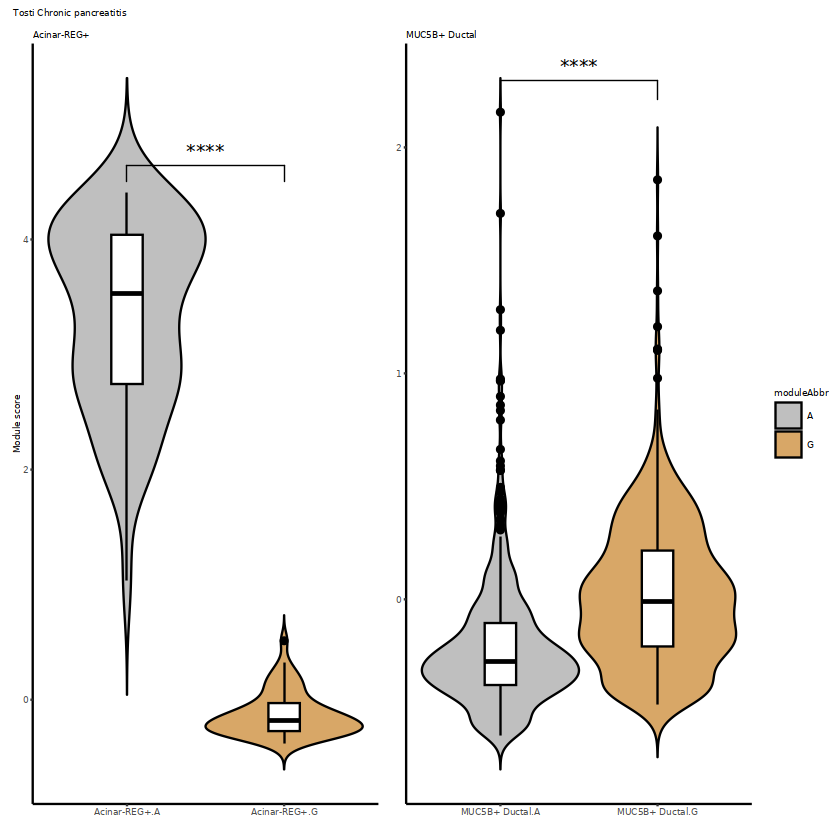

In [10]:
p.violins.list[["4a"]] <- makeViolinPlot(obj = obj.4a, 
                                         plotTitle = "Tosti Chronic pancreatitis", 
                                         col.celltype = "Cluster", 
                                         levels.celltype = c("Acinar-REG+", "MUC5B+ Ductal"),
                                         moduleA = "humanMarkers.pancreas_acinar", 
                                         moduleB = "humanMarkers.stomach_goblet", 
                                         moduleA.suffix = "A", 
                                         moduleB.suffix = "G", 
                                         rotation.xtick = 90)
p.violins.list[["4a"]]

ggsave(filename = "./plots/4a_violin.pdf", plot = p.violins.list[["4a"]], units = "in", width = 4, height = 3)

### 4b

In [11]:
# exclude "Acinar/MucinDuctal" from both acinar and metaplastic populations
acinarCells <- c("Acinar", "Acinar.Prolif")
metaplasticCells <- c("MucinDuctal")

mpi.acinar <- subset(x = ma.pinjury, subset = celltypeLabel %in% acinarCells)
mpi.metaplastic <- subset(x = ma.pinjury, subset = celltypeLabel %in% metaplasticCells)

obj.4b <- merge(mpi.acinar, y = mpi.metaplastic, add.cell.ids = c("Acinar", "Metaplastic"), project = "v1")
obj.4b@meta.data$cellType <- str_split_i(string = rownames(obj.4b@meta.data), pattern = "_", i = 1)
obj.4b
dim(obj.4b@meta.data)
head(obj.4b@meta.data)

An object of class Seurat 
32288 features across 8575 samples within 1 assay 
Active assay: RNA (32288 features, 0 variable features)

[1] 8575    9

,orig.ident,nCount_RNA,nFeature_RNA,clusters,celltypeLabel,cellBarcode,mouseMarkers.pancreas_acinar,mouseMarkers.stomach_goblet,cellType
,<chr>,<dbl>,<int>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>
Acinar_AAACCCATCCTTATAC.2wks.A8324,SeuratProject,9305,1419,0,Acinar,AAACCCATCCTTATAC-2wks-A8324,3.785456,-0.24436344,Acinar
Acinar_AAAGAACTCCGAACGC.2wks.A8324,SeuratProject,40611,2401,0,Acinar,AAAGAACTCCGAACGC-2wks-A8324,4.608911,-0.07517188,Acinar
Acinar_AAAGGATCAGCGTTGC.2wks.A8324,SeuratProject,7322,1611,8,Acinar,AAAGGATCAGCGTTGC-2wks-A8324,4.032710,-0.35207623,Acinar
Acinar_AAAGGATGTCGTTGGC.2wks.A8324,SeuratProject,7420,1420,0,Acinar,AAAGGATGTCGTTGGC-2wks-A8324,4.150388,-0.02786140,Acinar
Acinar_AAAGGTACAGACCCGT.2wks.A8324,SeuratProject,24759,2932,8,Acinar,AAAGGTACAGACCCGT-2wks-A8324,3.631851,0.33577333,Acinar
Acinar_AAAGTGATCAAGCTTG.2wks.A8324,SeuratProject,6215,1213,0,Acinar,AAAGTGATCAAGCTTG-2wks-A8324,4.148830,0.07508850,Acinar


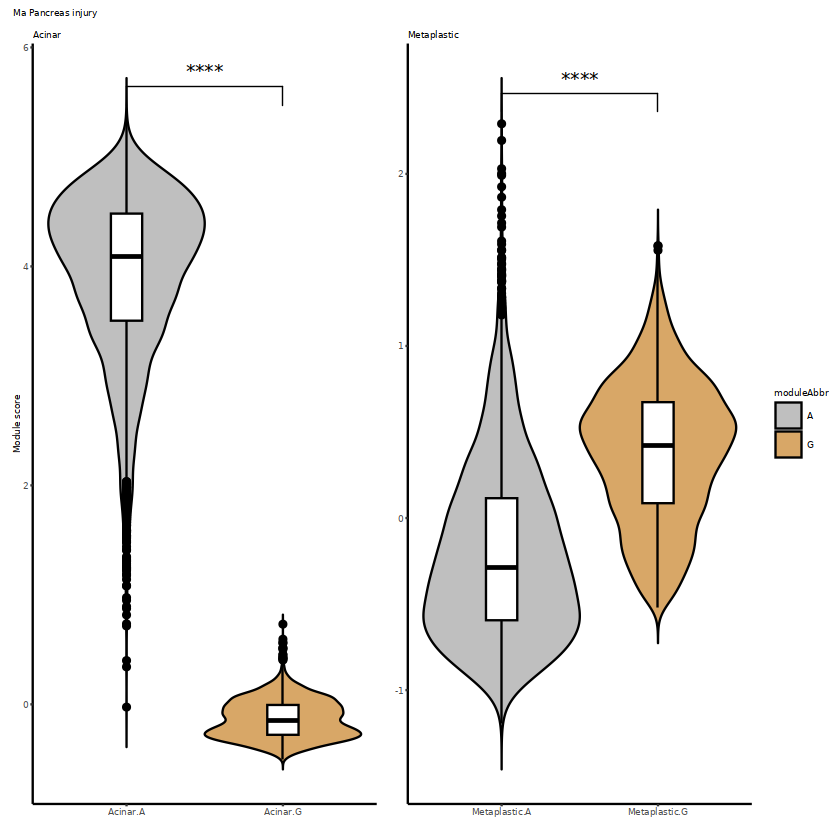

In [12]:
p.violins.list[["4b"]] <- makeViolinPlot(obj = obj.4b, 
                                         plotTitle = "Ma Pancreas injury", 
                                         col.celltype = "cellType", 
                                         moduleA = "mouseMarkers.pancreas_acinar", 
                                         moduleB = "mouseMarkers.stomach_goblet", 
                                         moduleA.suffix = "A", 
                                         moduleB.suffix = "G", 
                                         rotation.xtick = 0)
p.violins.list[["4b"]]

ggsave(filename = "./plots/4b_violin.pdf", plot = p.violins.list[["4b"]], units = "in", width = 4, height = 3)

### 4c

In [13]:
burdziak.pdac@meta.data <- burdziak.pdac@meta.data |> 
    mutate(condition = factor(condition, levels = c("N1", "N2", "K1", "K1.5", "K2", "K3", "K4", "K5", "K6"))) |> 
    mutate(cellstate = case_when(cluster == 0 ~ "Gastric-like", 
                                 cluster == 1 ~ "Progenitor-like (Nes+)", 
                                 cluster == 2 ~ "Acinar", 
                                 cluster == 3 ~ "ADM (KRAS-mut)",
                                 cluster == 4 ~ "PDAC-3", 
                                 cluster == 5 ~ "PDAC-1", 
                                 cluster %in% c(6, 8) ~ "PDAC-2", 
                                 cluster == 7 ~ "ADM (KRAS-WT)", 
                                 cluster == 9 ~ "Neuroendocrine-like", 
                                 cluster == 10 ~ "Macrophage-like", 
                                 cluster == 13 ~ "Tuft-like",
                                 .default = NA), 
           cellstate2 = case_when(cluster == 0 ~ "Gastric-like", 
                                 cluster == 1 ~ "Progenitor-like (Nes+)", 
                                 cluster == 2 ~ "Acinar", 
                                 cluster == 3 ~ "ADM (KRAS-mut)",
                                 cluster == 4 ~ "PDAC-3", 
                                 cluster == 5 ~ "PDAC-1", 
                                 cluster %in% c(6, 8) ~ "PDAC-2", 
                                 cluster == 7 ~ "ADM (KRAS-WT)", 
                                 cluster == 9 ~ "Neuroendocrine-like", 
                                 cluster == 10 ~ "Macrophage-like", 
                                 cluster == 13 ~ "Tuft-like",
                                 .default = as.character(cluster))) |> 
    mutate(cellstate = factor(cellstate, levels = c("Acinar", 
                                                    "ADM (KRAS-WT)", 
                                                    "Macrophage-like", 
                                                    "Gastric-like", 
                                                    "Progenitor-like (Nes+)",  
                                                    "ADM (KRAS-mut)",  
                                                    "Tuft-like",  
                                                    "Neuroendocrine-like", 
                                                    "PDAC-3", 
                                                    "PDAC-1", 
                                                    "PDAC-2")))

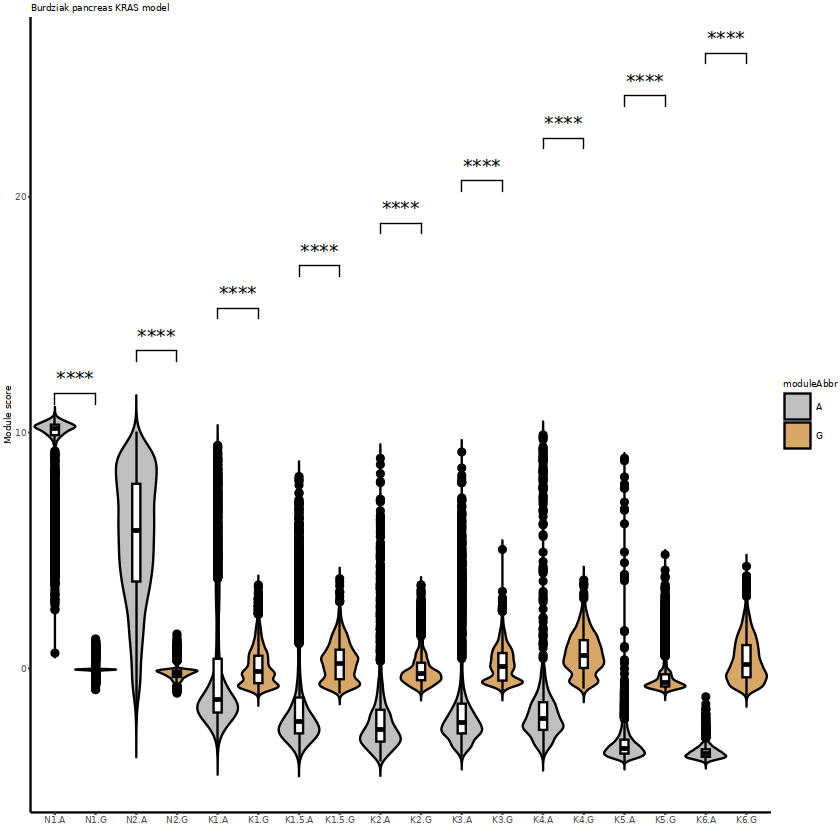

In [14]:
p.violins.list[["4c"]] <- makeViolinPlot2(obj = burdziak.pdac, 
                                          plotTitle = "Burdziak pancreas KRAS model", 
                                          col.celltype = "condition", 
                                          # levels.celltype = levels(burdziak_pancreas@meta.data$condition),
                                          moduleA = "mouseMarkers.pancreas_acinar", 
                                          moduleB = "mouseMarkers.stomach_goblet", 
                                          moduleA.suffix = "A", 
                                          moduleB.suffix = "G", 
                                          rotation.xtick = 0)

p.violins.list[["4c"]]

ggsave(filename = "./plots/4c_violin.pdf", plot = p.violins.list[["4c"]], units = "in", width = 8, height = 5)

### supp 5b

In [15]:
plotDF <- burdziak.pdac@meta.data  |>
    filter(!cellstate %in% c("Acinar", "ADM (KRAS-WT)", "Macrophage-like", NA))
# Extract all unique cellstates excluding NA
cellstates <- intersect(levels(plotDF$cellstate), unique(plotDF$cellstate))

# Generate pairs where one member is "Acinar"
pairs.cellstate <- lapply(setdiff(cellstates, "Gastric-like"), function(cs) c("Gastric-like", cs))

In [16]:
# Calculate median of `mouseMarkers.stomach_goblet` for each cellstate
ordered_cellstates <- plotDF |>
    group_by(cellstate) |>
    summarise(median_value = median(mouseMarkers.stomach_goblet, na.rm = TRUE)) |>
    arrange(desc(median_value)) |>
    pull(cellstate)

# Create gradient palette based on number of unique cellstates
gradient_colors <- colorRampPalette(c("#D8A767", "#FFFFFF"))(length(ordered_cellstates))
# Create a named color vector
color_map <- setNames(gradient_colors, ordered_cellstates)

# Update the factor levels for `cellstate` based on the ordering
plotDF <- plotDF |>
    mutate(cellstate = factor(cellstate, levels = ordered_cellstates))

# Generate comparisons: one member is "Gastric-like"
pairs.cellstate <- lapply(setdiff(ordered_cellstates, "Gastric-like"), function(cs) c("Gastric-like", cs))

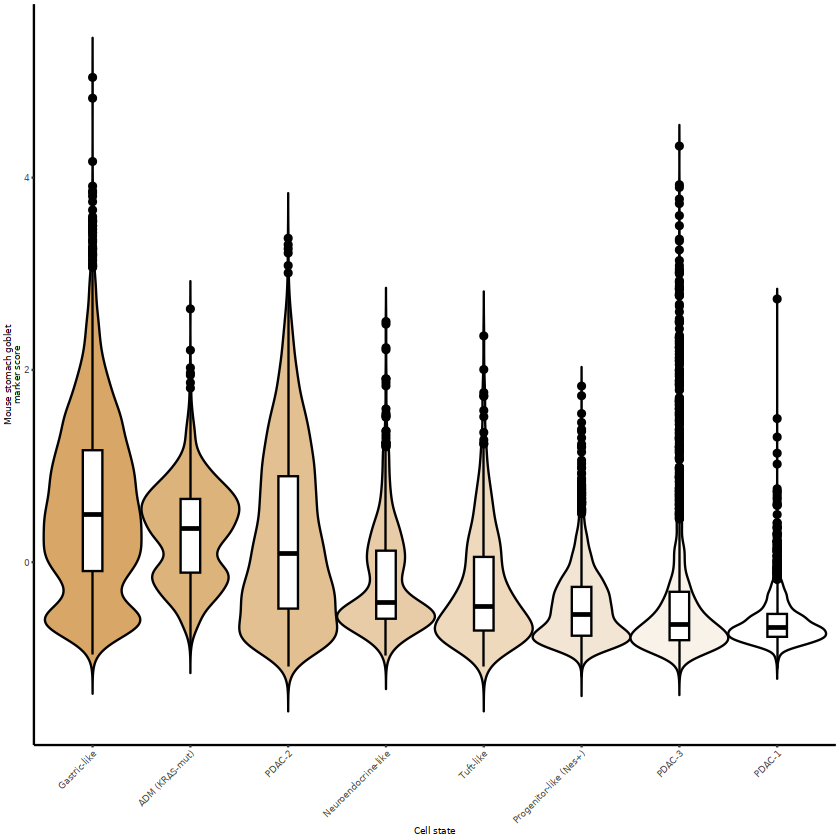

In [17]:
supp5b.violin <- plotDF  |>
    filter(!cellstate %in% c("Acinar", "ADM (KRAS-WT)", "Macrophage-like", "NA")) |>
    select(mouseMarkers.stomach_goblet, cellstate) |>
    ggpubr::ggviolin(x = "cellstate",
                     y = "mouseMarkers.stomach_goblet",
                     fill = "cellstate", 
                     scale = "width",
                     add = "boxplot", 
                     add.params = list(fill = "white")) +
    scale_fill_manual(values = color_map) + 
    ylab("Mouse stomach goblet\nmarker score") +
    xlab("Cell state") +
    custom_theme_classic +
    ggpubr::rotate_x_text(angle = 45) +
    theme(legend.position = "none")
supp5b.violin

### 4d

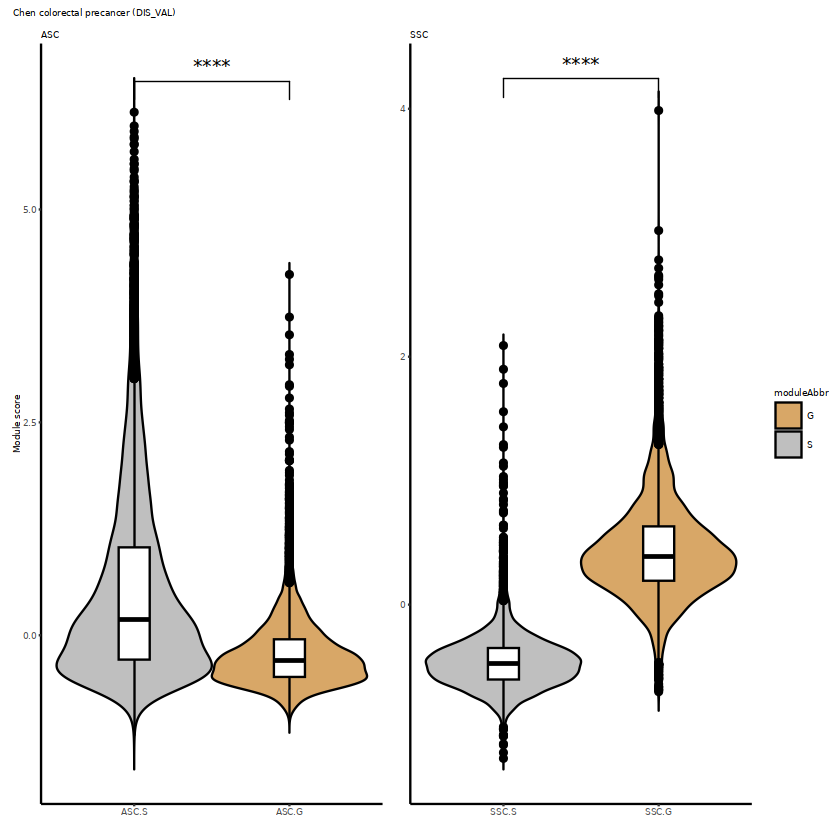

In [18]:
p.violins.list[["4d"]] <- makeViolinPlot(obj = chen.dis_val, 
                                         plotTitle = "Chen colorectal precancer (DIS_VAL)", 
                                         col.celltype = "Cell_Type", 
                                         levels.celltype = c("ASC", "SSC"),
                                         moduleA = "humanMarkers.colon_polyps.stem.ensg", 
                                         moduleB = "humanMarkers.colon_polyps.goblet.ensg", 
                                         moduleA.suffix = "S", 
                                         moduleB.suffix = "G", 
                                         rotation.xtick = 0)
p.violins.list[["4d"]]

ggsave(filename = "./plots/4d_violin.pdf", plot = p.violins.list[["4d"]], units = "in", width = 4, height = 3)

## stacked bar plot

### supp 5b

In [19]:
# Define the custom color palette
custom_colors <- c("N1" = "#E5E5E5", 
                   "N2" = "#BFBFBF", 
                   "K1" = "#F7EDE0", 
                   "K1.5" = "#F1E0CB", # Adjust shades for K1 and K1.5
                   "K2" = "#EBD2B3", 
                   "K3" = "#E9CDAA", 
                   "K4" = "#D8A767", 
                   "K5" = "#D8C3E7", 
                   "K6" = "#A26DC5")

# # color palette used in burdziak publication
# custom_colors <- c("N1" = "#D9F8A2", 
#                    "N2" = "#A0BF67", 
#                    "K1" = "#EFD13E", 
#                    "K1.5" = "#D5AB3D", # Adjust shades for K1 and K1.5
#                    "K2" = "#0E87E6", 
#                    "K3" = "#F9B9DF", 
#                    "K4" = "#D369A8", 
#                    "K5" = "#BF00DD", 
#                    "K6" = "#64009E")

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(colName)

  # Now:
  data %>% select(all_of(colName))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


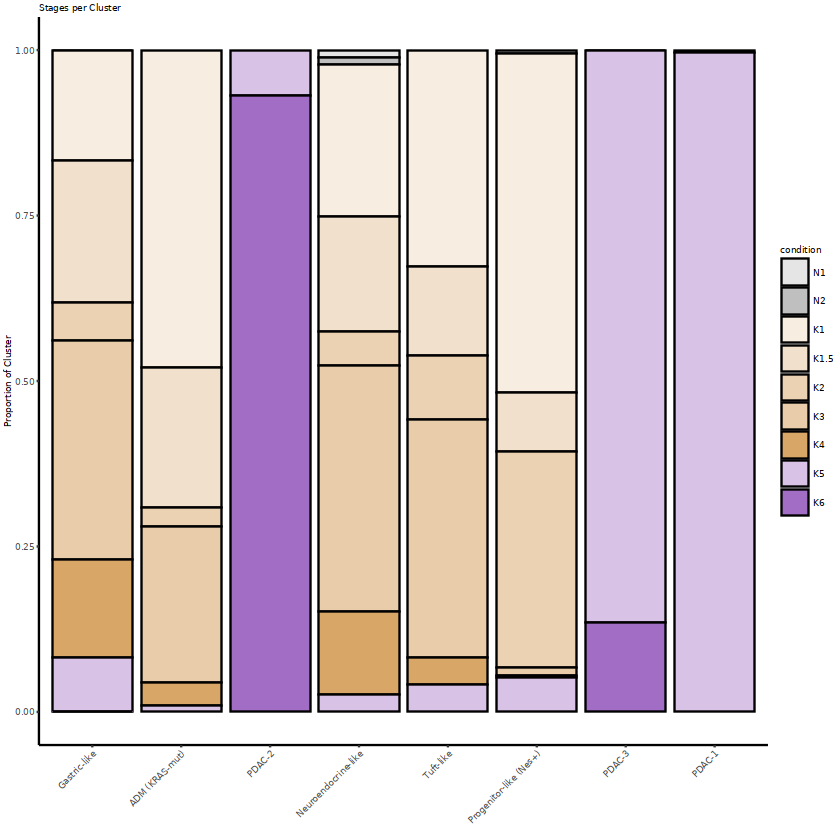

In [20]:
colName <- "cellstate"
supp5b.stack.ordered <- plotDF |> 
    select(colName, condition) |>
    group_by(condition, !!sym(colName)) |>
    count(.drop = F) |>
    ggplot(aes(x = !!sym(colName), y = n, fill = condition)) +
    geom_bar(stat = "identity", position = "fill", color = "black") +
    scale_fill_manual(values = custom_colors) +
    xlab("") + ylab("Proportion of Cluster") + ggtitle("Stages per Cluster") + 
    theme(panel.grid = element_blank()) + 
    custom_theme_classic +
    ggpubr::rotate_x_text(angle = 45)
supp5b.stack.ordered

## patchwork for supp 5b (stack + violin)

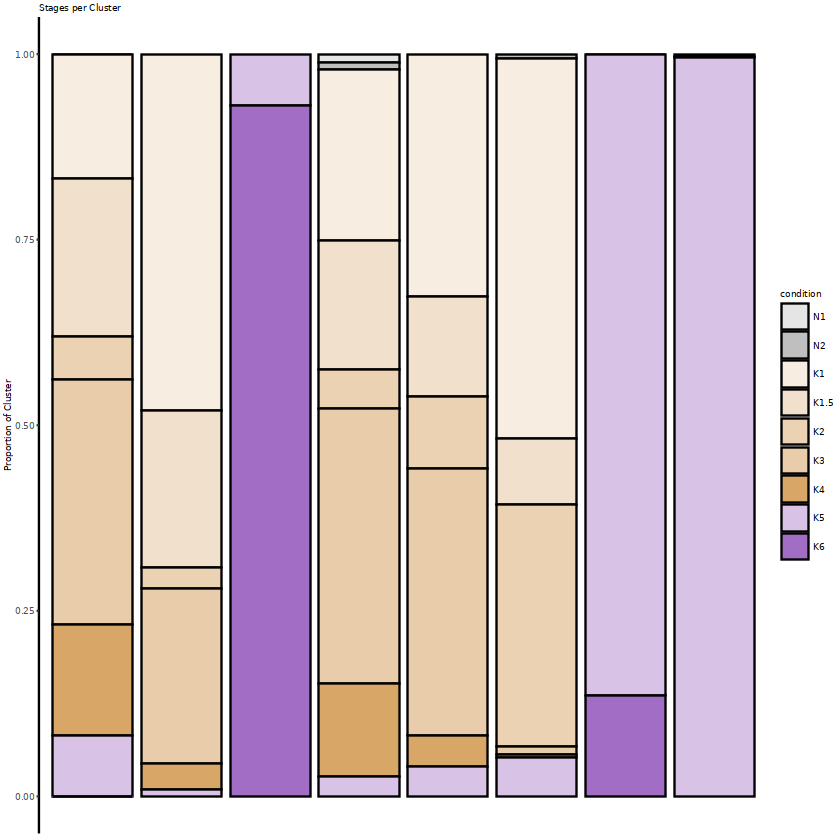

In [21]:
supp5b.stack.clean <- supp5b.stack.ordered +
  theme(axis.text.x = element_blank(),
        axis.title.x = element_blank(),
        axis.ticks.x = element_blank(), 
        axis.line.x = element_blank())
supp5b.stack.clean

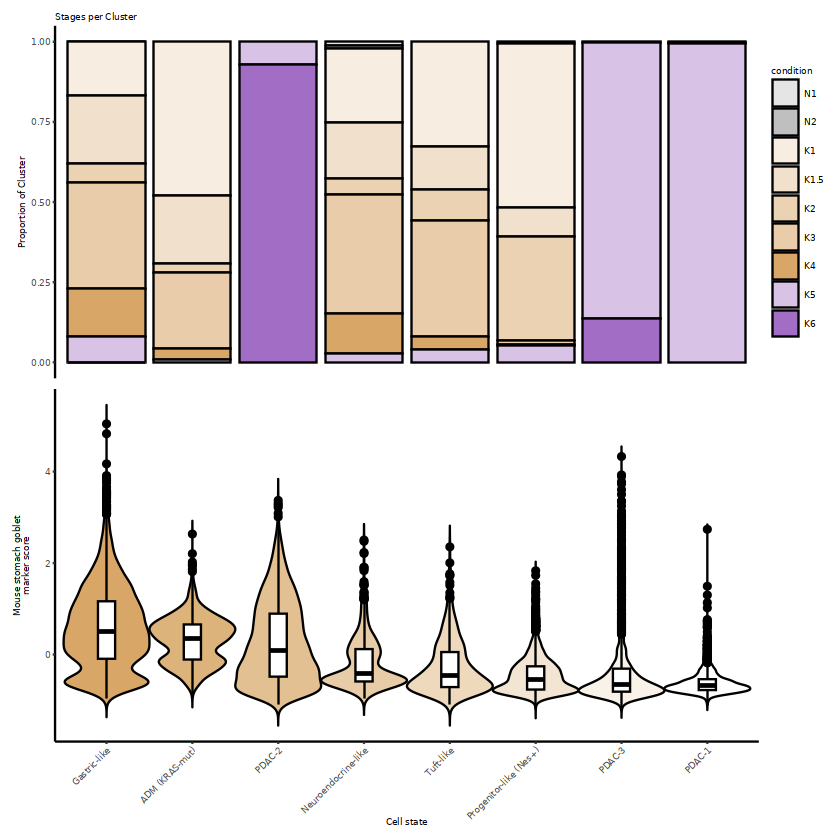

In [22]:
patchwork::wrap_plots(supp5b.stack.clean, supp5b.violin, nrow = 2) + patchwork::plot_layout(heights = c(1, 1))

# patchwork for supp 5b
ggsave(filename = "./plots/supp5b.pdf", 
       plot = (patchwork::wrap_plots(supp5b.stack.clean, supp5b.violin, nrow = 2) + 
                   patchwork::plot_layout(heights = c(1, 1))), 
       units = "in", width = 5, height = 6)